# Monte Carlo Methods

## Setting up the model

Arithmetic Asian call option:

$\bar{S}=\frac{1}{n}\sum^n_{i=1}S(t_i)$

Geometric Asian call option:

$\bar{S}=\left(\prod^n_{i=1} S(t_i)\right)^{\frac{1}{n}}$

The payoff's for each are then calculated as $\bar{S}-K$



The CEV model:



In [235]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.stats.qmc import Sobol
from scipy.stats import norm

In [257]:
# Drawing pseudo-random numbers
def draw_pseudo_random_numbers(seed, N, M):
    rng = np.random.default_rng(seed)
    return rng.standard_normal(size=(N, M))

def draw_quasi_random_numbers(seed, N, M):
    sobol_engine = Sobol(d=M, scramble=True, seed=seed)
    U = sobol_engine.random(n=N)
    return norm.ppf(U)

In [253]:
# Simulating paths
def sim_CEV_paths(seed, S0, r, sigma, gamma, T, M, N, euler=True, quasi=False):
    rng = np.random.default_rng(seed)
    dt = T / M
    sqrt_dt = np.sqrt(dt)
    logS = np.empty((N, M+1), dtype=float)
    logS[:, 0] = np.log(S0)
    if not quasi:
        Z = draw_pseudo_random_numbers(seed, N, M)
    else:
        Z = draw_quasi_random_numbers(seed, N, M)
    for n in range(M):
        logS_n = logS[:, n]
        S_n = np.exp(logS_n)
        dW = sqrt_dt * Z[:, n]
        # Ito's lemma for log S_t in CEV: d log S = (r - 0.5 * sigma^2 * S^{2gamma-2}) dt + sigma * S^{gamma-1} dW
        drift = (r - 0.5 * sigma**2 * np.power(S_n, 2*gamma-2)) * dt
        diffusion = sigma * np.power(S_n, gamma-1) * dW
        if euler:
            logS[:, n+1] = logS_n + drift + diffusion
        else:
            correction = 0.5 * sigma**2 * (gamma - 1) * np.power(S_n, 2*gamma-2) * (dW**2 - dt)
            logS[:, n+1] = logS_n + drift + diffusion + correction
    return np.exp(logS)

def price_asian_option(seed, S0, K, r, sigma, gamma, T, M, N, euler=True, quasi=False):
    S = sim_CEV_paths(seed, S0, r, sigma, gamma, T, M, N, euler, quasi)
    avg = S[:, 1:].mean(axis=1)  # Fixed: average over all time steps except initial value

    payoff = np.maximum(avg - K, 0.0)
    disc = np.exp(-r * T)
    disc_payoff = disc * payoff
    price = disc_payoff.mean()
    se = disc_payoff.std() / np.sqrt(N)
    ci95 = (price - 1.96 * se, price + 1.96 * se)
    return price, se, ci95


In [272]:
# parameters
seed = 42
S0 = 100
K = 100
r = 0.05
sigma = 1.25
gamma = 0.7
T = 1
M = 1
N = 2**20

In [239]:
milstein = price_asian_option(seed, S0, K, r, sigma, gamma, T, M, N, euler=False)
euler = price_asian_option(seed, S0, K, r, sigma, gamma, T, M, N, euler=True)

In [241]:
print("Using Milstein scheme:")
print(f"Asian Call Option Price: {milstein[0]:.4f}")
print(f"Standard Error: {milstein[1]:.8f}")
print(f"95% Confidence Interval: ({milstein[2][0]:.4f}, {milstein[2][1]:.4f})\n")

print("Using Euler scheme:")
print(f"Asian Call Option Price: {euler[0]:.4f}")
print(f"Standard Error: {euler[1]:.8f}")
print(f"95% Confidence Interval: ({euler[2][0]:.4f}, {euler[2][1]:.4f})")

Using Milstein scheme:
Asian Call Option Price: 8.2679
Standard Error: 0.03831987
95% Confidence Interval: (8.1928, 8.3430)

Using Euler scheme:
Asian Call Option Price: 8.2686
Standard Error: 0.03833462
95% Confidence Interval: (8.1934, 8.3437)


In [273]:
quasimm = price_asian_option(seed, S0, K, r, sigma, gamma, T, M, N, euler=False, quasi=True)
psuedomm = price_asian_option(seed, S0, K, r, sigma, gamma, T, M, N, euler=False, quasi=False)

In [274]:
print("Using Qausi-Monte Carlo:")
print(f"Asian Call Option Price: {quasimm[0]:.4f}")
print(f"Standard Error: {quasimm[1]:.8f}")
print(f"95% Confidence Interval: ({quasimm[2][0]:.4f}, {quasimm[2][1]:.4f})\n")

print("Using Crude Monte Carlo:")
print(f"Asian Call Option Price: {psuedomm[0]:.4f}")
print(f"Standard Error: {psuedomm[1]:.8f}")
print(f"95% Confidence Interval: ({psuedomm[2][0]:.4f}, {psuedomm[2][1]:.4f})")

Using Qausi-Monte Carlo:
Asian Call Option Price: 14.5292
Standard Error: 0.02114226
95% Confidence Interval: (14.4878, 14.5707)

Using Crude Monte Carlo:
Asian Call Option Price: 14.5310
Standard Error: 0.02115762
95% Confidence Interval: (14.4895, 14.5724)


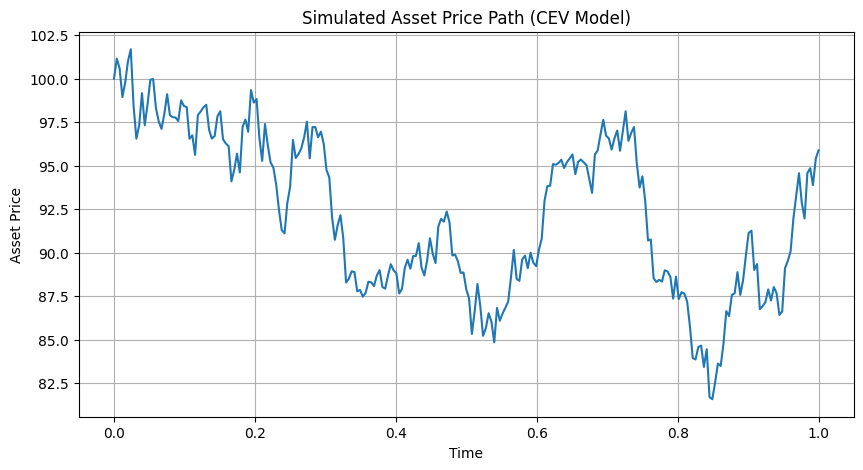

In [85]:
# Simulate one path and plot its movement
S_single = sim_CEV_paths(seed, S0, r, sigma, gamma, T, M, 1)[0]
plt.figure(figsize=(10, 5))
plt.plot(np.linspace(0, T, M+1), S_single)
plt.xlabel("Time")
plt.ylabel("Asset Price")
plt.title("Simulated Asset Price Path (CEV Model)")
plt.grid(True)
plt.show()

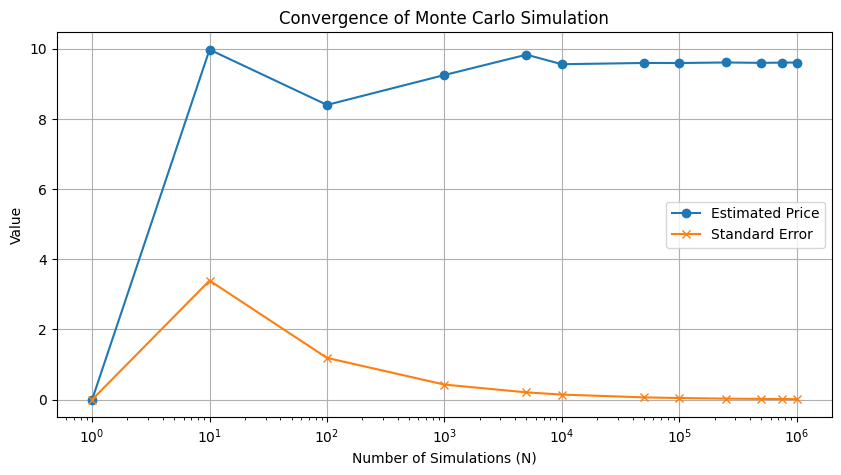

In [270]:
# plotting convergence
N_values = [1, 10, 100, 1000, 5000, 10000, 50000, 100000, 250000, 500000, 750000, 1000000]
prices = []
errors = []

for N in N_values:
    #print("Running for N =", N)
    price, se, _ = price_asian_option(seed, S0, K, r, sigma, gamma, T, M, N, euler=True)
    prices.append(price)
    errors.append(se)

plt.figure(figsize=(10, 5))
plt.plot(N_values, prices, marker='o', label='Estimated Price')
plt.plot(N_values, errors, marker='x', label='Standard Error')
plt.xscale('log')
plt.xlabel('Number of Simulations (N)')
plt.ylabel('Value')
plt.title('Convergence of Monte Carlo Simulation')
plt.legend()
plt.grid(True)
plt.show()

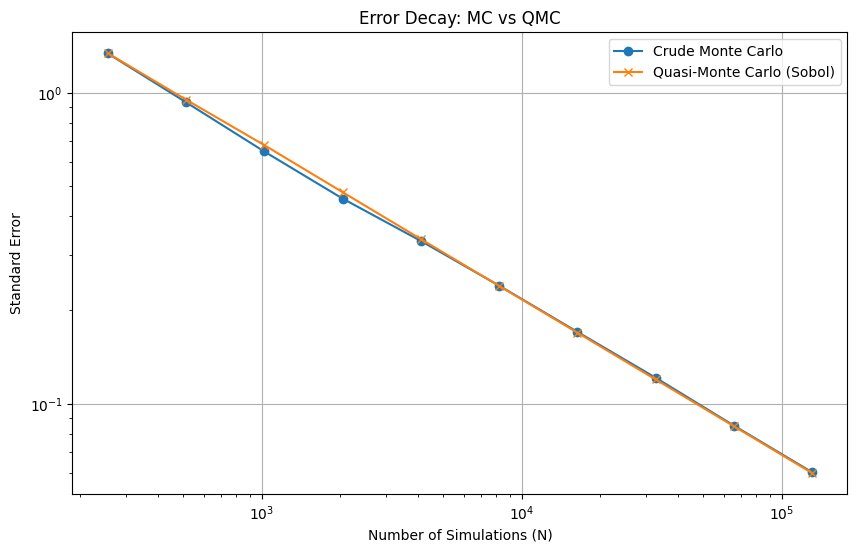

In [275]:
# Powers of 2 for Sobol
N_values = [2**i for i in range(8, 18)]  # 256 to 131072
mc_errors = []
qmc_errors = []

for N in N_values:
    _, mc_se, _ = price_asian_option(seed, S0, K, r, sigma, gamma, T, M, N, euler=False, quasi=False)
    _, qmc_se, _ = price_asian_option(seed, S0, K, r, sigma, gamma, T, M, N, euler=False, quasi=True)
    mc_errors.append(mc_se)
    qmc_errors.append(qmc_se)

plt.figure(figsize=(10, 6))
plt.plot(N_values, mc_errors, marker='o', label='Crude Monte Carlo')
plt.plot(N_values, qmc_errors, marker='x', label='Quasi-Monte Carlo (Sobol)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Simulations (N)')
plt.ylabel('Standard Error')
plt.title('Error Decay: MC vs QMC')
plt.legend()
plt.grid(True)
plt.show()